In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

,Unnamed: 0,loudness-0,loudness-1,loudness-2,bufmfcc_feats-0,bufmfcc_feats-1,bufmfcc_feats-2,bufmfcc_feats-3,bufmfcc_feats-4,bufmfcc_feats-5,bufmfcc_feats-6,spectral-0,spectral-1,spectral-2,spectral-3,spectral-4,spectral-5,spectral-6
0,0,-51.4342,-36.6695,0.002106,-70.0758,19.2796,14.6437,7.54190,6.99723,3.57703,3.27744,3065.63,5194.79,2.01363,6.12759,16303.40,-8.53502,37.6587
1,1,-53.5312,-37.1154,0.002393,-147.0830,28.8111,11.0022,7.68149,16.76340,22.23180,15.43690,1196.08,3366.37,3.95048,19.30820,7664.11,-18.33450,45.8841
2,2,-52.4212,-39.1286,0.008518,-157.4060,28.1211,22.3035,6.10722,12.63670,15.64370,9.17689,1863.19,4204.81,2.91582,10.94340,12888.10,-14.63200,39.6106
3,3,-41.3932,-30.7037,0.012904,-109.0320,35.1216,15.2952,19.82320,12.22360,16.62680,11.23820,1742.19,3627.94,3.10396,13.09330,9921.84,-15.53080,35.6156
4,4,-37.7853,-29.5644,0.012938,-96.3521,64.5556,17.5776,10.96490,16.07910,14.98540,9.11476,852.77,2359.05,5.57070,38.36430,3536.06,-23.45930,40.6362


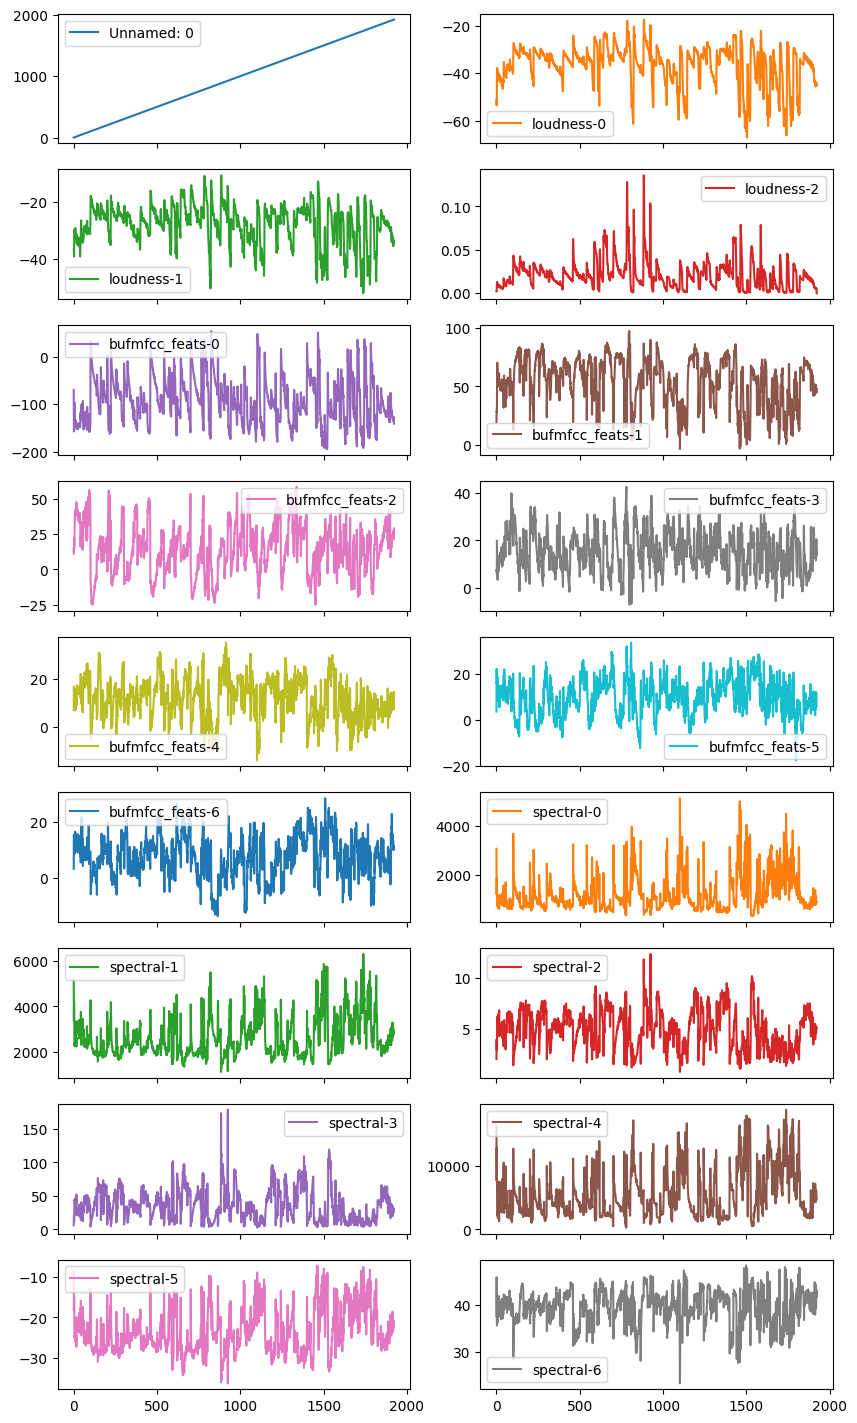

In [2]:
corpus_path = 'corpus_guitar/all_features/00_BN1-129-Eb_comp_mic.csv'
corpus_df = pd.read_csv(corpus_path)
corpus_df.plot(subplots=True, layout=(15,2), figsize=[10, 30])
corpus_df.head()

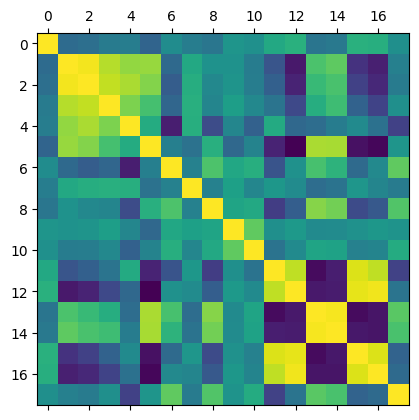

In [7]:
plt.matshow(corpus_df.corr())
plt.show()

,Unnamed: 0,loudness-0,loudness-1,loudness-2,bufmfcc_feats-0,bufmfcc_feats-1,bufmfcc_feats-2,bufmfcc_feats-3,bufmfcc_feats-4,bufmfcc_feats-5,bufmfcc_feats-6,spectral-0,spectral-1,spectral-2,spectral-3,spectral-4,spectral-5,spectral-6
1,1,-53.5312,-37.1154,0.002393,-147.0830,28.8111,11.0022,7.68149,16.76340,22.23180,15.43690,1196.080,3366.37,3.95048,19.3082,7664.11,-18.3345,45.8841
2,2,-52.4212,-39.1286,0.008518,-157.4060,28.1211,22.3035,6.10722,12.63670,15.64370,9.17689,1863.190,4204.81,2.91582,10.9434,12888.10,-14.6320,39.6106
3,3,-41.3932,-30.7037,0.012904,-109.0320,35.1216,15.2952,19.82320,12.22360,16.62680,11.23820,1742.190,3627.94,3.10396,13.0933,9921.84,-15.5308,35.6156
4,4,-37.7853,-29.5644,0.012938,-96.3521,64.5556,17.5776,10.96490,16.07910,14.98540,9.11476,852.770,2359.05,5.57070,38.3643,3536.06,-23.4593,40.6362
5,5,-37.7627,-29.5963,0.011398,-111.8720,70.1922,27.7939,7.04310,8.53135,12.42380,8.63578,804.701,2244.17,6.12512,44.8448,2616.69,-24.8402,37.6772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1918,1918,-45.3609,-35.4790,0.005744,-131.4150,51.2342,27.3109,11.84250,12.09520,8.36031,13.16820,1127.840,3020.19,4.52959,24.6244,5946.54,-20.5679,39.1834
1919,1919,-44.8164,-33.5164,0.006407,-128.6850,45.2805,25.3394,17.00410,7.26637,11.99620,9.89877,1012.110,2957.07,4.57893,25.5572,6132.14,-20.8631,41.5383
1920,1920,-43.8665,-33.5164,0.005373,-126.9350,44.9998,21.5830,20.50150,11.23730,10.14060,11.45140,916.321,2777.12,4.81807,28.5324,5492.18,-21.9673,43.1022
1921,1921,-45.3958,-34.4022,0.005463,-137.2610,44.5185,24.5213,13.54100,12.28870,6.86356,11.07260,913.132,2813.71,4.87489,28.4479,5043.41,-22.0069,43.2178


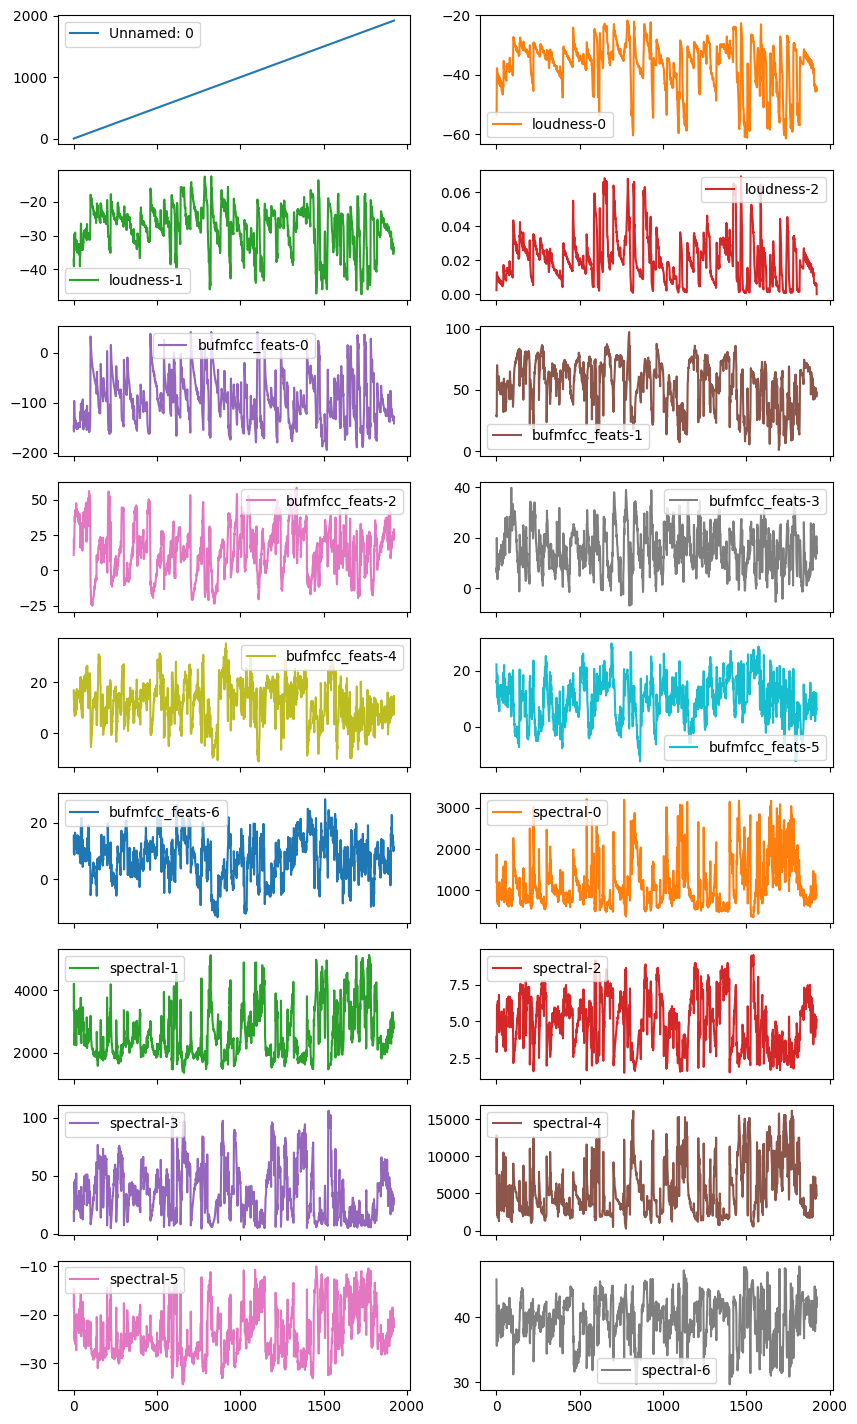

In [4]:
# remove outliers
corpus_df_no_outliers = corpus_df[(np.abs(stats.zscore(corpus_df)) < 3).all(axis=1)]
corpus_df_no_outliers.plot(subplots=True, layout=(15,2), figsize=[10, 30])
corpus_df_no_outliers

In [5]:
import os

corpus_files_names = ['sin']
target_corpus_path = 'corpus_static/all_features'
features_keep = ['loudness-0', 'loudness-1', 'loudness-2',
                 'spectral-0', 'spectral-1', 'spectral-2', 'spectral-3',
                 'spectral-4', 'spectral-5', 'spectral-6']
N_features = len(features_keep)
# LOAD TARGET CORPUS
print('Loading corpus files:')
target_features = np.ones((1, N_features))
target_files = []
for file_path in os.listdir(target_corpus_path):
    csv_path = os.path.join(target_corpus_path, file_path)
    if csv_path.endswith('.csv') and file_path.split('-')[0] in corpus_files_names:
        print(csv_path)
        corpus_song = pd.read_csv(csv_path)[features_keep].values
        target_files.append(corpus_song)
        target_features = np.concatenate([target_features, corpus_song], axis=0) # KEEP!!

target_features = target_features[1:,:]
target_features.shape

Loading corpus files:
corpus_static/all_features/sin-8.csv
corpus_static/all_features/sin-9.csv
corpus_static/all_features/sin-21.csv
corpus_static/all_features/sin-20.csv
corpus_static/all_features/sin-22.csv
corpus_static/all_features/sin-23.csv
corpus_static/all_features/sin-27.csv
corpus_static/all_features/sin-26.csv
corpus_static/all_features/sin-24.csv
corpus_static/all_features/sin-18.csv
corpus_static/all_features/sin-19.csv
corpus_static/all_features/sin-25.csv
corpus_static/all_features/sin-28.csv
corpus_static/all_features/sin-14.csv
corpus_static/all_features/sin-15.csv
corpus_static/all_features/sin-29.csv
corpus_static/all_features/sin-17.csv
corpus_static/all_features/sin-16.csv
corpus_static/all_features/sin-12.csv
corpus_static/all_features/sin-13.csv
corpus_static/all_features/sin-11.csv
corpus_static/all_features/sin-10.csv
corpus_static/all_features/sin-1.csv
corpus_static/all_features/sin-0.csv
corpus_static/all_features/sin-2.csv
corpus_static/all_features/sin-3.

(77546, 10)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_target_features = scaler.fit_transform(target_features)
target_files_scaled = [scaler.transform(target_file) for target_file in target_files]

scaled_target_features.mean(axis=0)
target_files_scaled[3].mean(axis=0)

array([-0.89140561, -1.05334117, -1.12041507,  0.67729737,  0.4395551 ,
       -1.18688198, -1.21773264,  0.59346726,  0.92558617,  0.38945841])

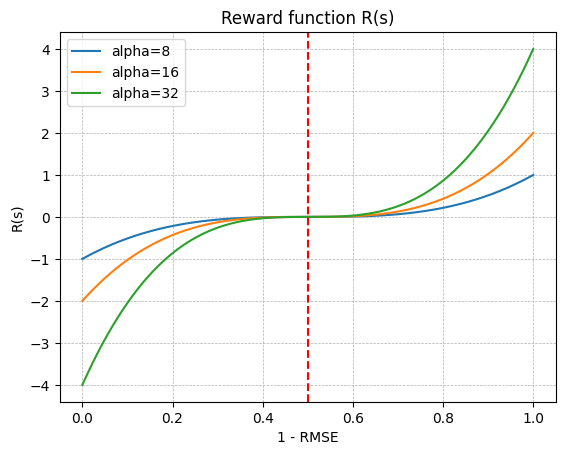

In [214]:
x = np.linspace(0, 1, num=1000)
y = 8*(x - 0.5)**3
z = 16*(x - 0.5)**3
w = 32*(x - 0.5)**3
plt.plot(x,y, label='alpha=8')
plt.plot(x,z, label='alpha=16')
plt.plot(x,w, label='alpha=32')
plt.axvline(x=0.5, ls='--', c='r')
plt.xlabel('1 - RMSE')
plt.ylabel('R(s)')
plt.title('Reward function R(s)')
plt.grid(linestyle = '--', linewidth = 0.5)
plt.legend()
plt.show()